In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet
from datetime import timedelta
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import numpy as np       

In [2]:
month_wise_employee_headcount = pd.read_excel(
  r'D:\surya.iyer\My Documents\projects\predictive analysis\PSIPL data\overall time series.xlsx',
  parse_dates=['month'],
  date_format={
      'month':'%Y-%m'
  }
)

In [25]:
month_wise_employee_headcount.shape

(284, 29)

In [3]:
month_wise_employee_headcount['budget'] = month_wise_employee_headcount['hr'] * 15_000 + month_wise_employee_headcount['operations'] * 25_000 + month_wise_employee_headcount['finance_and_accounts'] * 15_000 + month_wise_employee_headcount['administration'] * 30_000 + month_wise_employee_headcount['business'] * 27_000 + month_wise_employee_headcount['management'] * 28_000 + month_wise_employee_headcount['other_department']*15_000

In [4]:
month_wise_employee_headcount.columns

Index(['month', 'headcount', 'comp_id', 'male_count', 'female_count',
       'other_gender', 'hr', 'operations', 'finance_and_accounts',
       'administration', 'business', 'management', 'other_department', 'hindu',
       'muslim', 'christian', 'Age below 25', 'Age 25 to 35', 'Age 35 to 50',
       'Age above 50', 'new_joins', 'resigned_employees', 'growth_rate',
       'average_tenure_years', 'avg_ot_hours_per_emp', 'planned_leave_days',
       'unplanned_leave_days', 'absenteeism_rate', 'budget'],
      dtype='object')

### Old approach

In [5]:
configs = [
    {"seasonality_mode": "additive", "changepoint_prior_scale": 0.05},
    {"seasonality_mode": "additive", "changepoint_prior_scale": 0.5},
    {"seasonality_mode": "multiplicative", "changepoint_prior_scale": 0.05},
    {"seasonality_mode": "multiplicative", "changepoint_prior_scale": 0.5}
]

In [6]:
df_prophet = month_wise_employee_headcount.reset_index()[["month", "new_joins"]].rename(columns={"month": "ds", "new_joins": "y"})
forecast_horizon = 3
initial_train_size = int(len(df_prophet) * 0.8)

In [7]:
results = []

for config in configs:
    predictions = []
    actuals = []
    forecast_dates = []

    for start in range(initial_train_size, len(df_prophet) - forecast_horizon + 1):
        train = df_prophet.iloc[:start]
        test = df_prophet.iloc[start:start + forecast_horizon]

        # Prophet model with current config
        model = Prophet(
            seasonality_mode=config["seasonality_mode"],
            changepoint_prior_scale=config["changepoint_prior_scale"]
        )
        model.fit(train)

        future = model.make_future_dataframe(periods=forecast_horizon, freq='M')
        forecast = model.predict(future)

        forecast_values = forecast[["ds", "yhat"]].iloc[-forecast_horizon:]
        predictions.extend(forecast_values["yhat"].values)
        actuals.extend(test["y"].values)
        forecast_dates.extend(test["ds"].values)

    mae = mean_absolute_error(actuals, predictions)
    mse = mean_squared_error(actuals, predictions)
    results.append((config, mae, mse, predictions, actuals))

17:13:14 - cmdstanpy - INFO - Chain [1] start processing
17:13:14 - cmdstanpy - INFO - Chain [1] done processing
d:\surya.iyer\My Documents\projects\predictive analysis\.predictive\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
17:13:14 - cmdstanpy - INFO - Chain [1] start processing
17:13:14 - cmdstanpy - INFO - Chain [1] done processing
d:\surya.iyer\My Documents\projects\predictive analysis\.predictive\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
17:13:14 - cmdstanpy - INFO - Chain [1] start processing
17:13:14 - cmdstanpy - INFO - Chain [1] done processing
d:\surya.iyer\My Documents\projects\predictive analysis\.predictive\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future versio

KeyboardInterrupt: 

In [134]:
results = sorted(results, key=lambda x: x[1])
best_config, best_mae, best_mse, best_preds, best_actuals = results[0]

print(f"\nBest Config: {best_config}")
print(f"MAE: {best_mae:.2f}, MSE: {best_mse:.2f}")


Best Config: {'seasonality_mode': 'multiplicative', 'changepoint_prior_scale': 0.05}
MAE: 1.74, MSE: 10.20


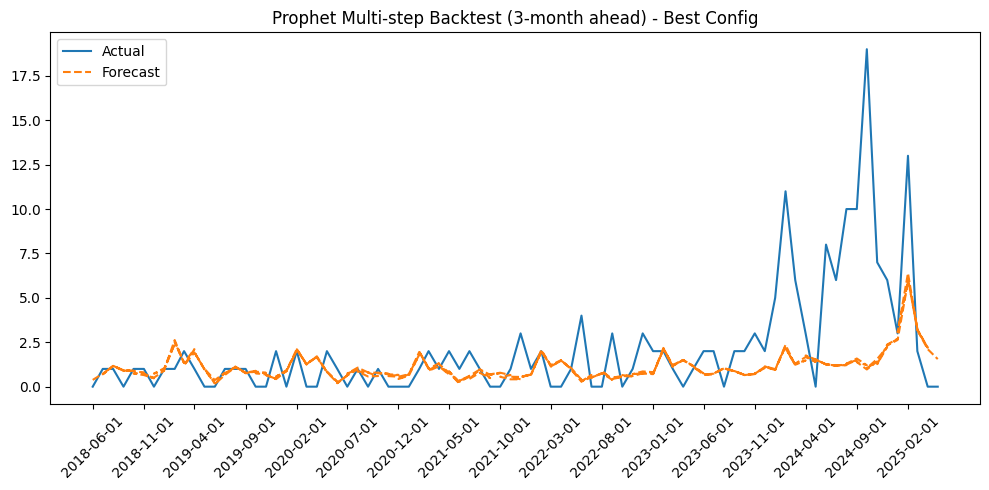

In [135]:
# test_dates = df_prophet["ds"].iloc[-len(best_actuals):]
plt.figure(figsize=(10, 5))
plt.plot(forecast_dates, best_actuals, label="Actual")
plt.plot(forecast_dates, best_preds, label="Forecast", linestyle="--")
plt.title(f"Prophet Multi-step Backtest ({forecast_horizon}-month ahead) - Best Config")
plt.legend()
plt.xticks(forecast_dates[::15])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [136]:
final_model = Prophet(
    seasonality_mode=best_config["seasonality_mode"],
    changepoint_prior_scale=best_config["changepoint_prior_scale"]
)
final_model.fit(df_prophet)

16:52:32 - cmdstanpy - INFO - Chain [1] start processing
16:52:32 - cmdstanpy - INFO - Chain [1] done processing


In [137]:
future = final_model.make_future_dataframe(periods=forecast_horizon + 10, freq='ME')
forecast = final_model.predict(future)

forecast.tail(forecast_horizon + 10)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
416,2025-05-31,3.791804,2.046609,6.320436,3.791804,3.791804,0.107056,0.107056,0.107056,0.107056,0.107056,0.107056,0.0,0.0,0.0,4.197737
417,2025-06-30,3.825517,0.725232,5.132172,3.825517,3.825517,-0.241899,-0.241899,-0.241899,-0.241899,-0.241899,-0.241899,0.0,0.0,0.0,2.900129
418,2025-07-31,3.860354,1.544903,5.874416,3.860354,3.860354,-0.039075,-0.039075,-0.039075,-0.039075,-0.039075,-0.039075,0.0,0.0,0.0,3.709513
419,2025-08-31,3.895191,2.172581,6.483772,3.895190,3.895411,0.116076,0.116076,0.116076,0.116076,0.116076,0.116076,0.0,0.0,0.0,4.347328
420,2025-09-30,3.928905,4.069748,8.357354,3.928413,3.929882,0.617263,0.617263,0.617263,0.617263,0.617263,0.617263,0.0,0.0,0.0,6.354072
421,2025-10-31,3.963742,1.282214,5.449959,3.962664,3.965534,-0.168041,-0.168041,-0.168041,-0.168041,-0.168041,-0.168041,0.0,0.0,0.0,3.297669
422,2025-11-30,3.997455,1.938457,6.240856,3.995690,4.000244,-0.020459,-0.020459,-0.020459,-0.020459,-0.020459,-0.020459,0.0,0.0,0.0,3.915670
423,2025-12-31,4.032292,1.315137,5.644925,4.029610,4.035671,-0.161778,-0.161778,-0.161778,-0.161778,-0.161778,-0.161778,0.0,0.0,0.0,3.379957
424,2026-01-31,4.067129,6.851752,11.208445,4.063422,4.071591,1.200089,1.200089,1.200089,1.200089,1.200089,1.200089,0.0,0.0,0.0,8.948045
425,2026-02-28,4.098595,1.163251,5.419624,4.093609,4.104712,-0.220039,-0.220039,-0.220039,-0.220039,-0.220039,-0.220039,0.0,0.0,0.0,3.196745


In [138]:
forecast.rename(columns={'ds':'Month'}, inplace=True)

In [139]:
forecast['Predicted new hire'] = forecast['trend'].round()

In [141]:
forecast.tail(forecast_horizon+10).to_excel('New_Hire_prediction.xlsx',index=False)

### New Approach

In [10]:
month_wise_employee_headcount.columns

Index(['month', 'headcount', 'comp_id', 'male_count', 'female_count',
       'other_gender', 'hr', 'operations', 'finance_and_accounts',
       'administration', 'business', 'management', 'other_department', 'hindu',
       'muslim', 'christian', 'Age below 25', 'Age 25 to 35', 'Age 35 to 50',
       'Age above 50', 'new_joins', 'resigned_employees', 'growth_rate',
       'average_tenure_years', 'avg_ot_hours_per_emp', 'planned_leave_days',
       'unplanned_leave_days', 'absenteeism_rate', 'budget'],
      dtype='object')

In [8]:
df_prophet = month_wise_employee_headcount[['month', 'new_joins']].rename(columns={'month': 'ds', 'new_joins': 'y'})

In [11]:
# Add exogenous factors as additional regressors
exogenous_factors = ['resigned_employees','growth_rate', 'average_tenure_years', 'avg_ot_hours_per_emp', 
                     'planned_leave_days', 'unplanned_leave_days', 'absenteeism_rate','budget','headcount']
for factor in exogenous_factors:
    df_prophet[factor] = month_wise_employee_headcount[factor]

In [12]:
future_exogenous = pd.DataFrame({'ds': pd.date_range(start=df_prophet['ds'].max() + timedelta(days=1), periods=12, freq='MS')})

In [13]:
# Forecast each exogenous factor separately
exogenous_forecasts = {}

for factor in exogenous_factors:
    temp_df = month_wise_employee_headcount[['month', factor, 'new_joins']].rename(columns={'month': 'ds', factor: 'y'})
    factor_model = Prophet()
    factor_model.fit(temp_df)

    forecast = factor_model.predict(future_exogenous)
    
    if factor in ['headcount', 'absenteeism_rate', 'resgined_employee', 'planned_leave_days','unplanned_leave_days','avg_ot_hrs_per_emp','growth_rate']:
        forecast['yhat'] = forecast['yhat'].clip(lower=0)
    
    exogenous_forecasts[factor] = forecast[['ds', 'yhat']].rename(columns={'yhat': factor})
    
    if factor in ['headcount','resgined_employee','budget','growth_rate']:
        exogenous_forecasts[factor] = exogenous_forecasts[factor].round()
    else:
        exogenous_forecasts[factor] = exogenous_forecasts[factor].round(2)
    
    
    future_exogenous = future_exogenous.merge(exogenous_forecasts[factor], on='ds', how='left')

17:14:35 - cmdstanpy - INFO - Chain [1] start processing
17:14:35 - cmdstanpy - INFO - Chain [1] done processing
17:14:35 - cmdstanpy - INFO - Chain [1] start processing
17:14:35 - cmdstanpy - INFO - Chain [1] done processing
17:14:35 - cmdstanpy - INFO - Chain [1] start processing
17:14:35 - cmdstanpy - INFO - Chain [1] done processing
17:14:35 - cmdstanpy - INFO - Chain [1] start processing
17:14:36 - cmdstanpy - INFO - Chain [1] done processing
17:14:36 - cmdstanpy - INFO - Chain [1] start processing
17:14:36 - cmdstanpy - INFO - Chain [1] done processing
17:14:36 - cmdstanpy - INFO - Chain [1] start processing
17:14:36 - cmdstanpy - INFO - Chain [1] done processing
17:14:36 - cmdstanpy - INFO - Chain [1] start processing
17:14:36 - cmdstanpy - INFO - Chain [1] done processing
17:14:36 - cmdstanpy - INFO - Chain [1] start processing
17:14:36 - cmdstanpy - INFO - Chain [1] done processing
17:14:36 - cmdstanpy - INFO - Chain [1] start processing
17:14:36 - cmdstanpy - INFO - Chain [1]

In [14]:
future_exogenous

,ds,resigned_employees,growth_rate,average_tenure_years,avg_ot_hours_per_emp,planned_leave_days,unplanned_leave_days,absenteeism_rate,budget,headcount
0,2025-07-01,986.87,0.0,2.29,0.15,33.25,5.67,0.01,388818916.0,15640.0
1,2025-08-01,938.62,0.0,2.29,0.16,33.85,5.77,0.01,393312379.0,15815.0
2,2025-09-01,961.94,0.0,2.30,0.16,34.40,5.86,0.01,397184227.0,15968.0
3,2025-10-01,1191.25,2.0,2.30,0.16,34.95,5.92,0.01,402182931.0,16165.0
4,2025-11-01,1045.07,0.0,2.29,0.17,35.66,6.00,0.01,398480572.0,16026.0
5,2025-12-01,1084.95,0.0,2.30,0.17,36.00,5.99,0.01,399757221.0,16077.0
6,2026-01-01,1005.89,4.0,2.30,0.17,36.28,5.99,0.01,399520628.0,16069.0
7,2026-02-01,1003.04,0.0,2.26,0.17,36.40,5.94,0.01,400713865.0,16121.0
8,2026-03-01,1125.69,0.0,2.28,0.18,38.03,13.56,0.01,403510980.0,16231.0
9,2026-04-01,1097.88,0.0,2.29,0.18,46.62,7.05,0.01,405599418.0,16312.0


In [15]:
hiring_model = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True, growth='flat')

for factor in exogenous_factors:
    hiring_model.add_regressor(factor)

hiring_model.fit(df_prophet)

17:14:48 - cmdstanpy - INFO - Chain [1] start processing
17:14:48 - cmdstanpy - INFO - Chain [1] done processing


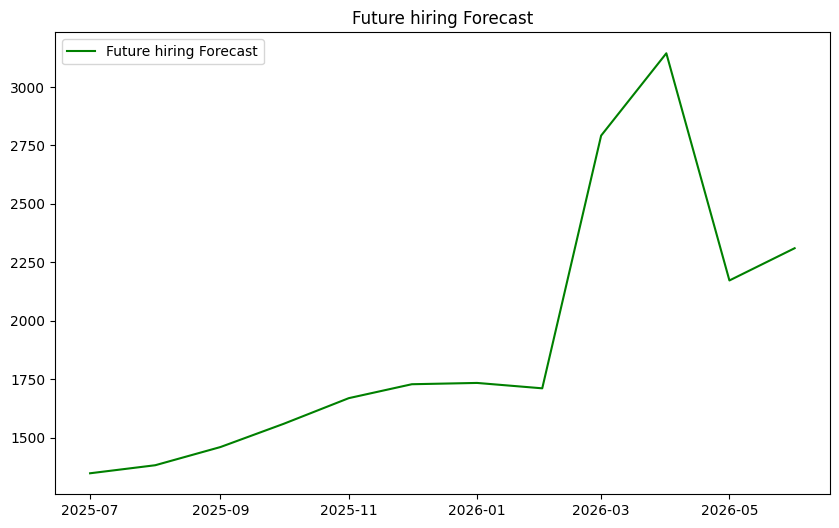

In [16]:
forecast_headcount = hiring_model.predict(future_exogenous)

# Plot the future forecast of headcount
plt.figure(figsize=(10, 6))
plt.plot(forecast_headcount['ds'], forecast_headcount['yhat'], label='Future hiring Forecast', color='green')
plt.title('Future hiring Forecast')
plt.legend()
plt.show()

In [21]:
Hiring_prediction = pd.concat(
    [
        future_exogenous[['ds','absenteeism_rate','average_tenure_years','avg_ot_hours_per_emp','budget','headcount','resigned_employees','unplanned_leave_days']],
        forecast_headcount['yhat']
    ],
    axis=1
).rename(columns={'yhat':'Predicted Hiring','ds':'Month'})

In [23]:
Hiring_prediction['Predicted Hiring'] = Hiring_prediction['Predicted Hiring'].round()

In [24]:
Hiring_prediction.to_excel(r'D:\surya.iyer\My Documents\projects\predictive analysis\PSIPL model predictions\hiring_prediction.xlsx',index=False,)